
--- Linearised resultant tension solution ---
H = -7138646.46 N
V0 = 2103241.36 N
Resultant tension T = sqrt(H^2 + V0^2) = 7442035.84 N
Tangent stiffness matrix K_T = dF/dU [N/m]:
[[-7820.51479555  1959.69624841]
 [ -273.4004644   -910.02986719]]
Jacobian J_T = dU/dF [m/N]:
[[-1.18916432e-04 -2.56079602e-04]
 [ 3.57260888e-05 -1.02193098e-03]]
Horizontal stiffness k_xx = -7820.51 N/m
Computed horizontal span = 848.67 m
Computed vertical drop = -250.00 m
Anchor horizontal target = 848.67 m, achieved = 848.67 m (error -0.00 m)


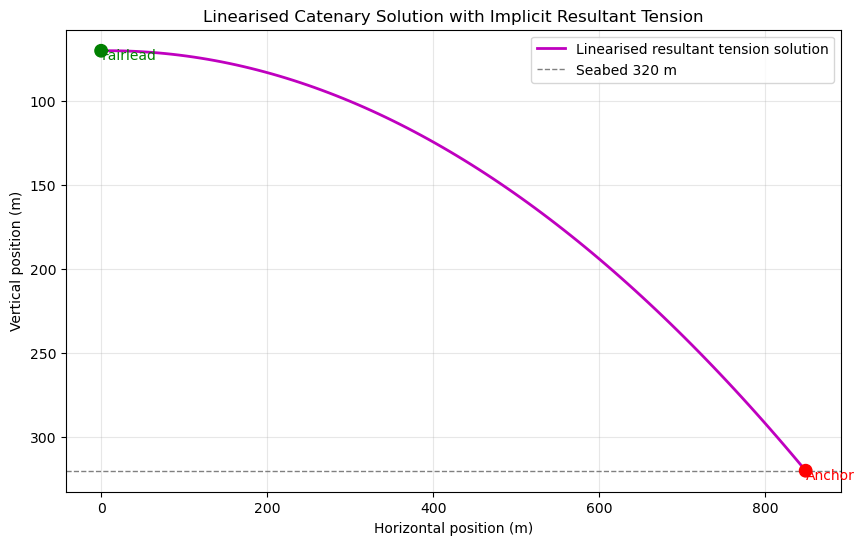

In [37]:
#Packages Used
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import *
from sympy import symbols, Function

# Mooring line constants
r_anchor_centerline = 853.87 # m
r_fairlead_centerline = 5.2    # m
x_anchor = r_anchor_centerline - r_fairlead_centerline
Unstretched_L = 902.2  # m
D_moor = 0.09  # m
Mooring_line_density = 77.7066  # kg/m
W_moor = 698.094  # N/m
EA_moor = 384243000  # N
z_fairlead = -70  # fairlead depth below SWL
z_anchor = -320  # anchor depth below SWL
dz_total = z_anchor - z_fairlead  # vertical drop from fairlead to anchor

# Linearisation about the static equilibrium position.
# Keep the equilibrium force direction and adjust the magnitude until the vertical drop matches.
H_eq = 1.5e7 #Initial guess for horizontal tension at equilibrium (N)
V0_eq = 10e5 

T_eq = np.hypot(H_eq, V0_eq)
force_direction = np.array([H_eq, V0_eq]) / T_eq #kept constant during linearisation


import scipy.optimize

# Explicit analytic catenary end-point equations.
def elastic_catenary_end(H, V0, L, W, EA):
    x_end = H * L / EA + H * L / W  * (
        np.arcsinh(V0 / H) - np.arcsinh((V0 - W) / H)
    )
    z_end = W * L / EA * (V0 / W - 0.5) + H * L / W * (
        np.sqrt(1 + (V0 / H) ** 2) - np.sqrt(1 + ((V0 - W) / H) ** 2)
    )
    return x_end, z_end
def catenary_residuals(vars):
    H, V0 = vars
    x_end, z_end = elastic_catenary_end(
        H, V0,
        Unstretched_L,
        W_moor,
        EA_moor
    )

    return [
        x_end - x_anchor,
        z_end - dz_total
    ]
def elastic_catenary_shape(H, V0, L, W, EA, num_points=100):
    s = np.linspace(0, L, num_points)

    x_line = (
    H*s/EA
    + H*L/W * (
        np.arcsinh(V0/H)
        - np.arcsinh((V0 - W*s/L)/H)
    )
)
   
    z_line = (
    (V0*s - 0.5*W*s**2/L)/EA
    + H*s/W * (
        np.sqrt(1 + (V0/H)**2)
        - np.sqrt(1 + ((V0 - W*s/L)/H)**2)
    )
)

    return x_line, z_line, x_line[-1], z_line[-1]

# Residual function for root finding: Vertical drop to match dz_total.
initial_guess = np.array([H_eq, V0_eq])

sol = scipy.optimize.root(catenary_residuals, initial_guess, method='hybr')
if not sol.success:
    raise RuntimeError(f'Root solve failed: {sol.message}')
H_T, V0_T = sol.x
x_line_T, z_line_T, x_end_T, z_end_T = elastic_catenary_shape(H_T, V0_T, Unstretched_L, W_moor, EA_moor)
z_line_T_abs = -z_fairlead - z_line_T

T_resultant = np.hypot(H_T, V0_T)



def tangent_stiffness(H, V0, L, W, EA):
    # Compute the tangent stiffness matrix dF/dU at the given H and V0.
    # This involves differentiating the catenary equations with respect to H and V0.
    delta = 1e-6 # Perturbation size for finite difference
    x_end, z_end = elastic_catenary_end(H, V0, L, W, EA)
    
    # Perturb H
    x_end_H_plus, z_end_H_plus = elastic_catenary_end(H + delta, V0, L, W, EA)
    x_end_H_minus, z_end_H_minus = elastic_catenary_end(H - delta, V0, L, W, EA)
    
    # Perturb V0
    x_end_V0_plus, z_end_V0_plus = elastic_catenary_end(H, V0 + delta, L, W, EA)
    x_end_V0_minus, z_end_V0_minus = elastic_catenary_end(H, V0 - delta, L, W, EA)
    
    # Compute derivatives
    dx_dH = (x_end_H_plus - x_end_H_minus) / (2 * delta)
    dz_dH = (z_end_H_plus - z_end_H_minus) / (2 * delta)
    
    dx_dV0 = (x_end_V0_plus - x_end_V0_minus) / (2 * delta)
    dz_dV0 = (z_end_V0_plus - z_end_V0_minus) / (2 * delta)
    
    # Construct the Jacobian matrix dF/dU
    J_T = np.array([[dx_dH, dx_dV0],
                    [dz_dH, dz_dV0]])
    
    # Invert to get dU/dF
    K_T = np.linalg.inv(J_T)
    
    return K_T, J_T

K_T, J_T = tangent_stiffness(H_T, V0_T, Unstretched_L, W_moor, EA_moor)

print('\n--- Linearised resultant tension solution ---')
print(f'H = {H_T:.2f} N')
print(f'V0 = {V0_T:.2f} N')
print(f'Resultant tension T = sqrt(H^2 + V0^2) = {T_resultant:.2f} N')
print('Tangent stiffness matrix K_T = dF/dU [N/m]:')
print(K_T)
print('Jacobian J_T = dU/dF [m/N]:')
print(J_T)
print(f'Horizontal stiffness k_xx = {K_T[0,0]:.2f} N/m')
print(f'Computed horizontal span = {x_end_T:.2f} m')
print(f'Computed vertical drop = {z_end_T:.2f} m')
print(f'Anchor horizontal target = {x_anchor:.2f} m, achieved = {x_end_T:.2f} m (error {x_end_T - x_anchor:.2f} m)')

plt.figure(figsize=(10,6))

plt.plot(x_line_T, z_line_T_abs, '-m', linewidth=2, label='Linearised resultant tension solution')
plt.axhline(320, color='gray', linewidth=1, linestyle='--', label='Seabed 320 m')
plt.scatter([0.0, x_anchor], [-z_fairlead, -z_anchor], c=['green', 'red'], s=80, zorder=5)
plt.text(0.0, -z_fairlead + 5, 'Fairlead', color='green')
plt.text(x_anchor, -z_anchor + 5, 'Anchor', color='red')
plt.title('Linearised Catenary Solution with Implicit Resultant Tension')
plt.xlabel('Horizontal position (m)')
plt.ylabel('Vertical position (m)')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.legend()
plt.show()